# 📌 Support Vector Machine (SVM) – End-to-End Revision Notes

---

## 🔹 What is SVM?

**Support Vector Machine (SVM)** is a **supervised machine learning algorithm** used for:

* **Classification**
* **Regression**

> 🎯 **Main Goal:** Find the **optimal hyperplane** that separates classes with the **maximum margin**.

---

## 🔹 Hyperplane

A **hyperplane** is the decision boundary that separates data points.

**Mathematical form:**

```
w · x + b = 0
```

* **w** → weight vector
* **b** → bias
* **x** → input features

---

## 🔹 Margin (Very Important ⭐)

**Margin** is the distance between the hyperplane and the nearest data points.

> ✅ SVM always tries to **maximize the margin** → better generalization.

---

## 🔹 Support Vectors

**Support vectors** are:

* The **closest data points** to the hyperplane
* They **completely define** the position of the hyperplane

⚠️ Removing non-support vectors does **not** change the model.

---

## 🔹 Hard Margin SVM

### 📌 Concept

* Assumes data is **perfectly linearly separable**
* **No misclassification allowed**

### 📌 Constraint

```
yᵢ (w · xᵢ + b) ≥ 1
```

### 📌 Objective Function

```
min (1/2)||w||²
```

### ❌ Limitations

* Very sensitive to **outliers**
* Rarely works on real-world data

---

## 🔹 Soft Margin SVM (Most Important ⭐⭐⭐)

### 📌 Why Soft Margin?

Real-world data is:

* Noisy
* Not perfectly separable

So SVM allows **some misclassification**.

---

## 🔹 Slack Variables (ξ)

* Allow margin violations
* Measure degree of misclassification

```
ξᵢ ≥ 0
```

---

## 🔹 Soft Margin Constraints

```
yᵢ (w · xᵢ + b) ≥ 1 − ξᵢ
```

---

## 🔹 Final Optimization Form (EXAM GOLD ⭐⭐⭐)

```
min (1/2)||w||² + C Σ ξᵢ
```

**Subject to:**

```
yᵢ (w · xᵢ + b) ≥ 1 − ξᵢ
ξᵢ ≥ 0
```

---

## 🔹 Regularization Parameter (C)

Controls **trade-off** between:

* Large margin
* Classification error

| Value of C | Effect                                            |
| ---------- | ------------------------------------------------- |
| Large C    | Less error, smaller margin (overfitting risk)     |
| Small C    | Larger margin, more error (better generalization) |

---

## 🔹 Hard Margin vs Soft Margin

| Feature           | Hard Margin   | Soft Margin |
| ----------------- | ------------- | ----------- |
| Misclassification | ❌ Not allowed | ✅ Allowed   |
| Noise handling    | ❌ Poor        | ✅ Good      |
| Practical use     | Rare          | Very common |

---

## 🔹 Loss Function – Hinge Loss 

```
L = max(0, 1 − y(w · x + b))
```

Used to penalize:

* Points inside margin
* Misclassified points

---

## 🔹 Kernel Trick (High-Level)

Used when data is **not linearly separable**.

> Maps data into **higher-dimensional space** without explicit computation.

### Common Kernels:

* Linear
* Polynomial
* RBF (Gaussian)
* Sigmoid

---

## 🔹 Why SVM is Powerful

✅ Works well in high-dimensional space
✅ Effective when features > samples
✅ Strong theoretical foundation

---

## 🔹 What You DON’T Need to Remember ❌

* Lagrangian derivation
* KKT conditions
* Dual optimization math

👉 **Final form + intuition is enough** for exams, interviews, and real projects.

---

## 🔹 One-Line Ultimate Summary 

> **SVM finds an optimal hyperplane by maximizing margin while penalizing misclassification using parameter C.**

---



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from sklearn.datasets import load_breast_cancer
data =  load_breast_cancer()

In [10]:
X_df = pd.DataFrame(data.data, columns=data.feature_names)
y_df = pd.DataFrame(data.target, columns=['target'])
df = pd.concat([X_df, y_df], axis=1)

In [11]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


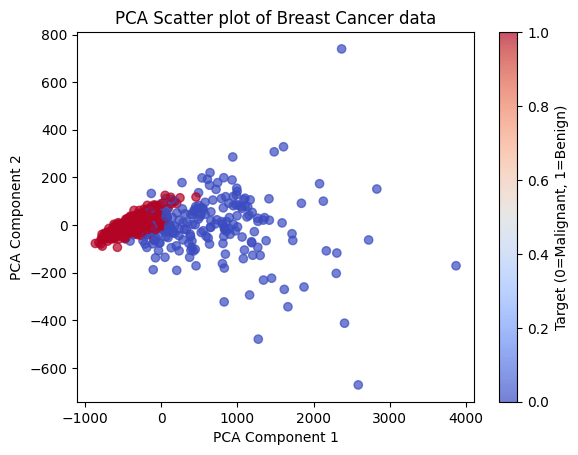

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.drop('target', axis=1))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['target'],
            cmap='coolwarm', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Scatter plot of Breast Cancer data')
plt.colorbar(label='Target (0=Malignant, 1=Benign)')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(X_df , y_df , test_size= 0.2 , random_state=42)

In [14]:
from sklearn.svm import SVC
from sklearn.preprocessing  import StandardScaler
from sklearn.pipeline import make_pipeline

In [15]:
pipe = make_pipeline(
    StandardScaler(),
    SVC()
)

In [17]:
pipe.fit(x_train , y_train)

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,steps,"[('standardscaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [18]:
y_pred = pipe.predict(x_test)

In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.9824561403508771

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}


grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)


grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


Fitting 5 folds for each of 72 candidates, totalling 360 fits


c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,"Pipeline(step...svc', SVC())])"
,param_grid,"{'svc__C': [0.1, 1, ...], 'svc__gamma': ['scale', 'auto', ...], 'svc__kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best Cross-Validation Score: 0.9736263736263737
Best Estimator: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=0.1, kernel='linear'))])


In [ ]:
y_pred_grid = grid_search.predict(x_test)
test_accuracy = accuracy_score(y_test, y_pred_grid)
print(f"Test Accuracy with Best Model: {test_accuracy}")

Test Accuracy with Best Model: 0.9824561403508771
